In [13]:
# Cellule 2 - Toutes les bibliothèques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision import models
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import random
from datetime import datetime

print("✓ Tous les imports réussis!")
print(f"PyTorch: {torch.__version__}")
print(f"TorchVision: {torchvision.__version__}")

✓ Tous les imports réussis!
PyTorch: 2.5.1
TorchVision: 0.20.1


In [17]:
# Cellule 3 - Configuration GPU/CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé: {device}")

SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

CLASSES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"Nombre de classes: {len(CLASSES)}")
print(f"Classes: {CLASSES}")

Device utilisé: cpu
Nombre de classes: 10
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [18]:
# Cellule 4 - Data augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("✓ Transformations définies")
print(f"Train transform: {train_transform}")
print(f"Test transform: {test_transform}")

✓ Transformations définies
Train transform: Compose(
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=(0.5,), std=(0.5,))
)
Test transform: Compose(
    ToTensor()
    Normalize(mean=(0.5,), std=(0.5,))
)


In [19]:
# Cellule 5 - Téléchargement de FashionMNIST
print("Téléchargement de FashionMNIST...")

train_dataset = torchvision.datasets.FashionMNIST(
    root='data', train=True, download=True, transform=train_transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='data', train=False, download=True, transform=test_transform
)

print(f"✓ Dataset chargé!")
print(f"Train dataset taille: {len(train_dataset)}")
print(f"Test dataset taille: {len(test_dataset)}")

# Afficher une image exemple
image, label = train_dataset[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label} ({CLASSES[label]})")

Téléchargement de FashionMNIST...
✓ Dataset chargé!
Train dataset taille: 60000
Test dataset taille: 10000
Image shape: torch.Size([1, 28, 28])
Label: 9 (Ankle boot)


In [20]:
# Cellule 6 - Création du jeu de validation
val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size

train_dataset, val_dataset = random_split(
    train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Train size (after split): {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size (after split): 54000
Validation size: 6000
Test size: 10000


In [21]:
# Cellule 7 - Création des DataLoaders
BATCH_SIZE = 64

# Sur Windows, mettre num_workers=0 pour éviter les erreurs
import platform
num_workers = 0 if platform.system() == 'Windows' else 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                         shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, 
                       shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, 
                        shuffle=False, num_workers=num_workers)

print(f"✓ DataLoaders créés")
print(f"Nombre de batches train: {len(train_loader)}")
print(f"Nombre de batches val: {len(val_loader)}")
print(f"Nombre de batches test: {len(test_loader)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Num workers: {num_workers}")

✓ DataLoaders créés
Nombre de batches train: 844
Nombre de batches val: 94
Nombre de batches test: 157
Batch size: 64
Num workers: 0


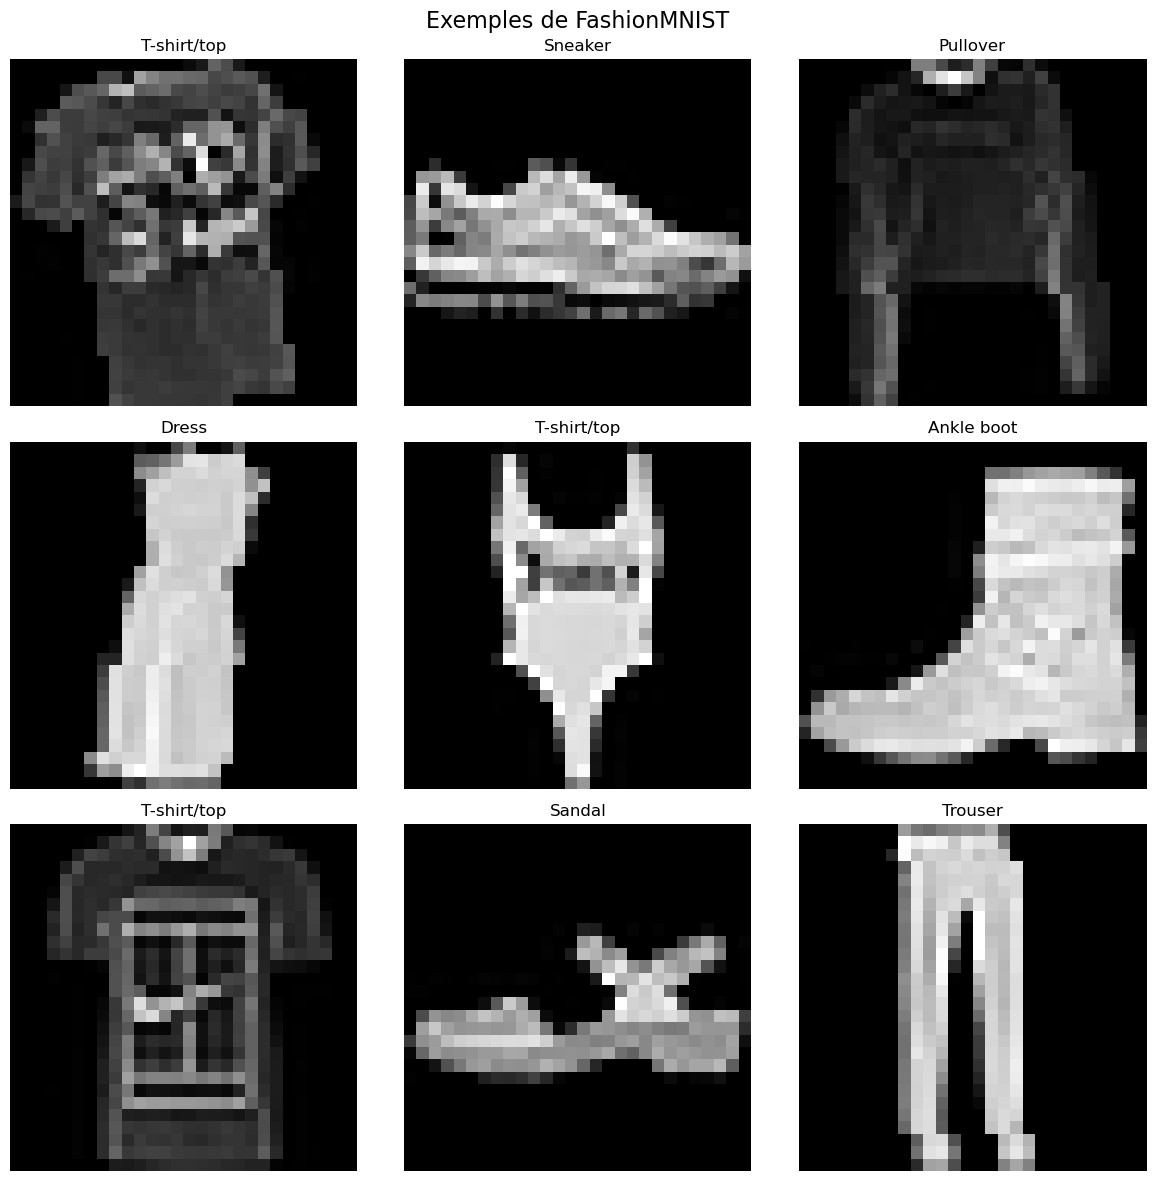

In [22]:
# Cellule 8 - Affichage d'échantillons
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(9):
    idx = random.randint(0, len(train_dataset) - 1)
    img, label = train_dataset[idx]
    
    # Si l'image est un tuple (à cause du random_split)
    if isinstance(img, tuple):
        img = img[0]
    
    ax = axes[i // 3, i % 3]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"{CLASSES[label]}", fontsize=12)
    ax.axis('off')

plt.suptitle("Exemples de FashionMNIST", fontsize=16)
plt.tight_layout()
plt.show()

In [23]:
# Cellule 9 - Architecture du réseau
class FashionCNNImproved(nn.Module):
    def __init__(self, input_channels=1, num_classes=10, dropout_rate=0.3):
        super(FashionCNNImproved, self).__init__()
        
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        
        self.feature_size = 128 * 3 * 3
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.feature_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.classifier(x)
        return x

# Instancier le modèle
model = FashionCNNImproved().to(device)

# Afficher l'architecture
print(model)
print(f"\nNombre total de paramètres: {sum(p.numel() for p in model.parameters()):,}")

FashionCNNImproved(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.3, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mo

In [24]:
# Cellule 10 - Fonctions utilitaires
def accuracy_fn(y_true, y_pred):
    """Calcule l'accuracy en pourcentage"""
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Entraîne pour une époque"""
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_acc += accuracy_fn(target, output.argmax(dim=1))
        
        # Afficher progression
        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)} - Loss: {loss.item():.4f}")
    
    avg_loss = running_loss / len(train_loader)
    avg_acc = running_acc / len(train_loader)
    
    return avg_loss, avg_acc

def evaluate(model, data_loader, criterion, device):
    """Évalue le modèle sur un dataset"""
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            total_loss += loss.item()
            total_acc += accuracy_fn(target, output.argmax(dim=1))
            
            all_preds.extend(output.argmax(dim=1).cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    avg_acc = total_acc / len(data_loader)
    
    return avg_loss, avg_acc, all_preds, all_targets

print("✓ Fonctions définies")

✓ Fonctions définies


In [25]:
# Cellule 11 - Initialisation de l'optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, verbose=True)

print("✓ Optimiseur et loss function configurés")
print(f"Learning rate initial: {optimizer.param_groups[0]['lr']}")

✓ Optimiseur et loss function configurés
Learning rate initial: 0.001


In [26]:
# Cellule 12 - Entraînement (à exécuter en dernier)
NUM_EPOCHS = 10  # Vous pouvez réduire à 5 si trop long
train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("Début de l'entraînement...")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)
    
    # Entraînement
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    # Validation
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    
    # Mise à jour du learning rate
    scheduler.step(val_loss)
    
    # Sauvegarde des métriques
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"✓ Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"✓ Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"  Learning rate: {optimizer.param_groups[0]['lr']:.6f}")

print("\n" + "=" * 60)
print("✓ Entraînement terminé!")

Début de l'entraînement...

Epoch 1/10
----------------------------------------
  Batch 100/844 - Loss: 0.9387
  Batch 200/844 - Loss: 0.8314
  Batch 300/844 - Loss: 0.4628
  Batch 400/844 - Loss: 0.5114
  Batch 500/844 - Loss: 0.4033
  Batch 600/844 - Loss: 0.4032
  Batch 700/844 - Loss: 0.6113
  Batch 800/844 - Loss: 0.5494
✓ Train Loss: 0.6729 | Train Acc: 75.18%
✓ Val Loss: 0.4164 | Val Acc: 84.40%
  Learning rate: 0.001000

Epoch 2/10
----------------------------------------
  Batch 100/844 - Loss: 0.4638
  Batch 200/844 - Loss: 0.5975
  Batch 300/844 - Loss: 0.5406
  Batch 400/844 - Loss: 0.3854
  Batch 500/844 - Loss: 0.6305
  Batch 600/844 - Loss: 0.4188
  Batch 700/844 - Loss: 0.4191
  Batch 800/844 - Loss: 0.3193
✓ Train Loss: 0.4444 | Train Acc: 83.95%
✓ Val Loss: 0.3522 | Val Acc: 87.10%
  Learning rate: 0.001000

Epoch 3/10
----------------------------------------
  Batch 100/844 - Loss: 0.4756
  Batch 200/844 - Loss: 0.4806
  Batch 300/844 - Loss: 0.3142
  Batch 400/844 -

In [27]:
# Cellule 13 - Test final
print("Évaluation sur le jeu de test...")
test_loss, test_acc, test_preds, test_targets = evaluate(model, test_loader, criterion, device)

print(f"\n📊 RÉSULTATS FINAUX:")
print(f"Loss sur le test: {test_loss:.4f}")
print(f"Accuracy sur le test: {test_acc:.2f}%")

Évaluation sur le jeu de test...

📊 RÉSULTATS FINAUX:
Loss sur le test: 0.2431
Accuracy sur le test: 91.04%


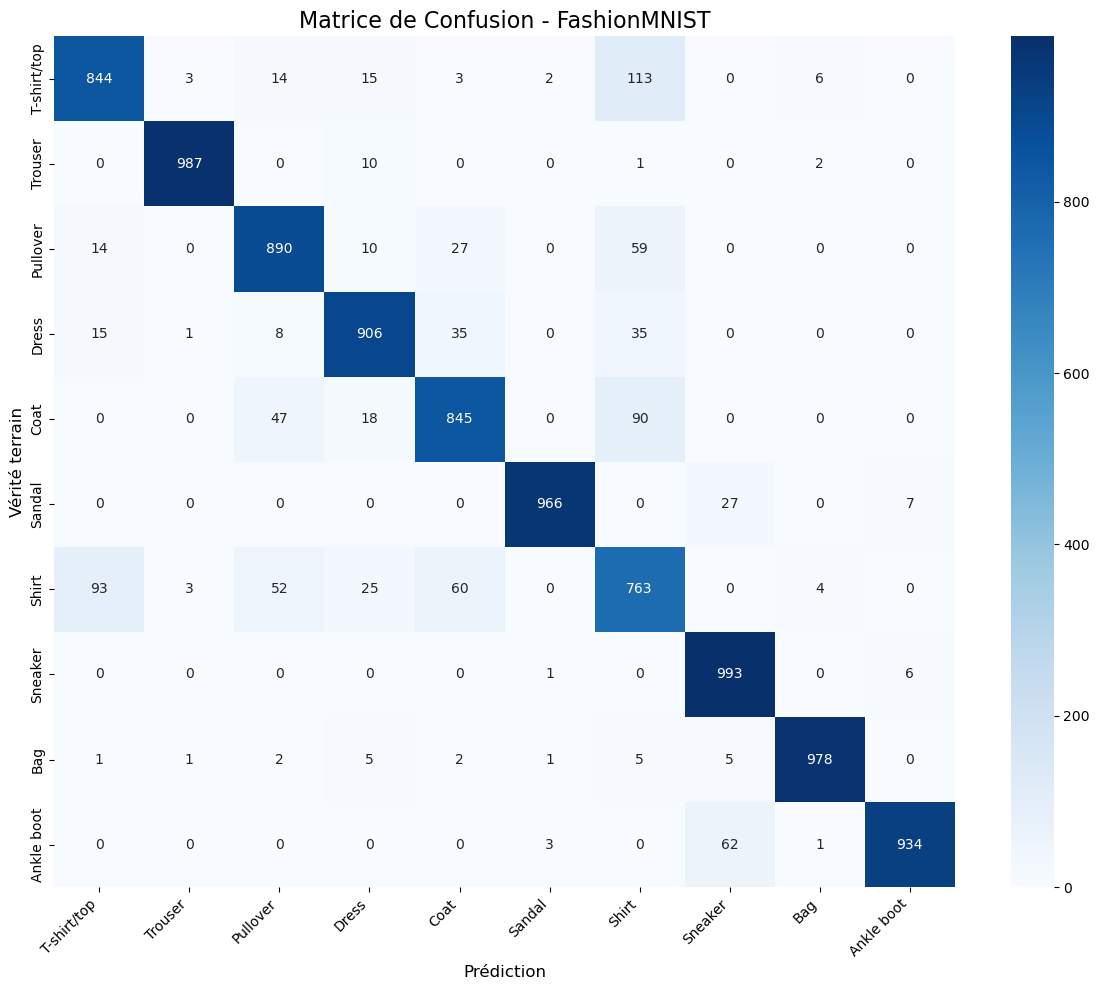

In [28]:
# Cellule 14 - Visualisation des résultats
cm = confusion_matrix(test_targets, test_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Matrice de Confusion - FashionMNIST', fontsize=16)
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Vérité terrain', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [29]:
# Cellule 15 - Rapport détaillé
print("📋 RAPPORT DE CLASSIFICATION:")
print("=" * 60)
print(classification_report(test_targets, test_preds, target_names=CLASSES))

📋 RAPPORT DE CLASSIFICATION:
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.84      0.86      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.88      0.89      0.88      1000
       Dress       0.92      0.91      0.91      1000
        Coat       0.87      0.84      0.86      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.72      0.76      0.74      1000
     Sneaker       0.91      0.99      0.95      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.99      0.93      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



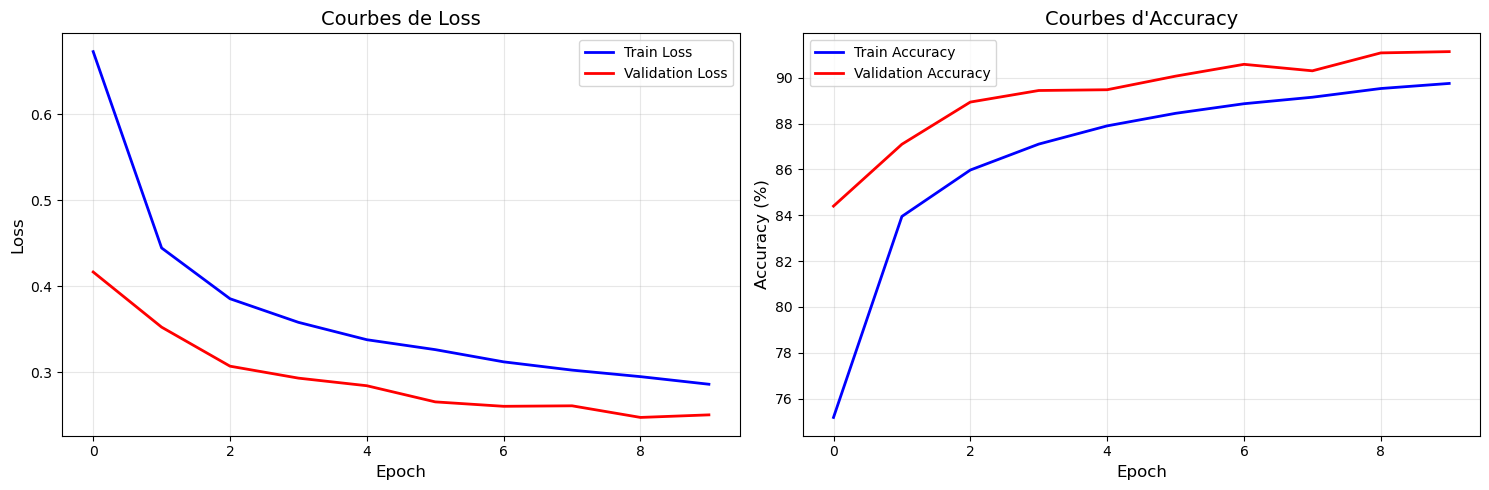


📈 Meilleure accuracy validation: 91.13%
📈 Meilleure accuracy test: 91.04%


In [30]:
# Cellule 16 - Visualisation des courbes
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Courbe de loss
axes[0].plot(train_losses, 'b-', label='Train Loss', linewidth=2)
axes[0].plot(val_losses, 'r-', label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Courbes de Loss', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Courbe d'accuracy
axes[1].plot(train_accs, 'b-', label='Train Accuracy', linewidth=2)
axes[1].plot(val_accs, 'r-', label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title("Courbes d'Accuracy", fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📈 Meilleure accuracy validation: {max(val_accs):.2f}%")
print(f"📈 Meilleure accuracy test: {test_acc:.2f}%")

In [31]:
# Cellule 17 - Sauvegarde
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = f'fashion_mnist_model_{timestamp}.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'test_accuracy': test_acc,
    'test_loss': test_loss,
    'classes': CLASSES
}, model_path)

print(f"✓ Modèle sauvegardé: {model_path}")

# Option: Sauvegarder les prédictions
import json
results = {
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'best_val_accuracy': float(max(val_accs)),
    'epochs': NUM_EPOCHS,
    'batch_size': BATCH_SIZE
}

with open(f'results_{timestamp}.json', 'w') as f:
    json.dump(results, f, indent=4)
    
print("✓ Résultats sauvegardés")

✓ Modèle sauvegardé: fashion_mnist_model_20260530_195320.pth
✓ Résultats sauvegardés


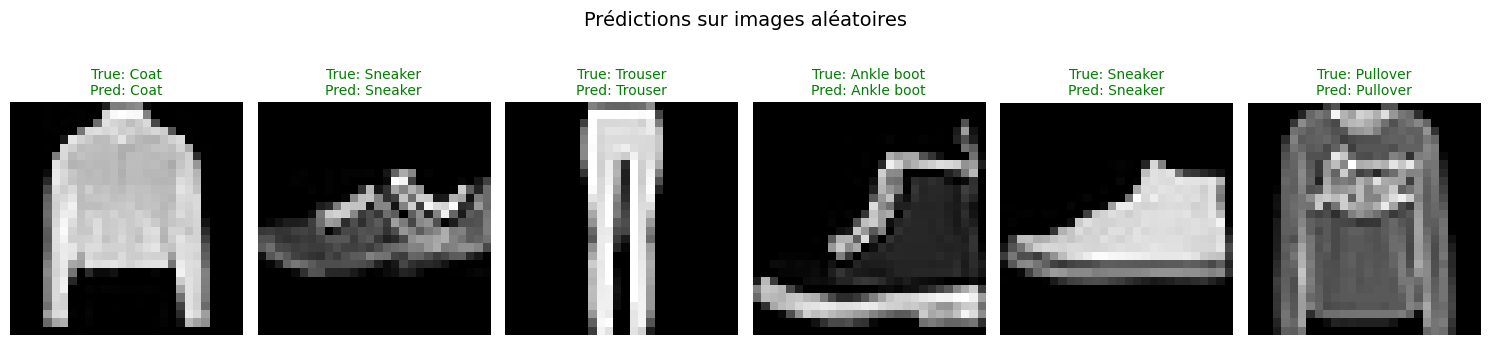

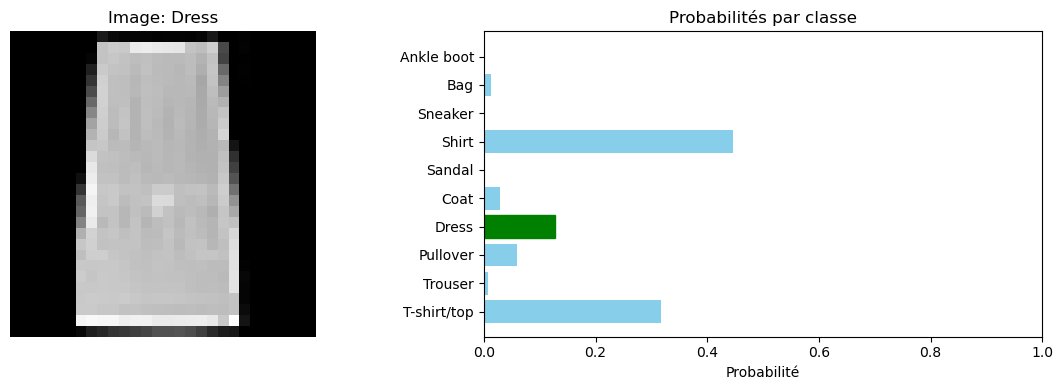

In [32]:
# Cellule 17: Test sur des images aléatoires
def predict_random_images(model, dataset, num_images=5):
    """Prédit sur des images aléatoires et visualise"""
    model.eval()
    indices = random.sample(range(len(dataset)), num_images)
    
    fig, axes = plt.subplots(1, num_images, figsize=(15, 4))
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]
            
            # Préparation pour le modèle
            if isinstance(img, tuple):
                img_tensor = img[0].unsqueeze(0).to(device)
            else:
                img_tensor = img.unsqueeze(0).to(device)
            
            # Prédiction
            output = model(img_tensor)
            pred_label = output.argmax(dim=1).item()
            
            # Affichage
            axes[i].imshow(img.squeeze(), cmap='gray')
            color = 'green' if pred_label == true_label else 'red'
            axes[i].set_title(f'True: {CLASSES[true_label]}\nPred: {CLASSES[pred_label]}', 
                             color=color, fontsize=10)
            axes[i].axis('off')
    
    plt.suptitle('Prédictions sur images aléatoires', fontsize=14)
    plt.tight_layout()
    plt.show()

# Tester sur des images du jeu de test
predict_random_images(model, test_dataset, num_images=6)

# Probabilités de prédiction
def show_prediction_probs(model, dataset, idx):
    """Affiche les probabilités de prédiction pour une image"""
    model.eval()
    img, true_label = dataset[idx]
    
    with torch.no_grad():
        if isinstance(img, tuple):
            img_tensor = img[0].unsqueeze(0).to(device)
        else:
            img_tensor = img.unsqueeze(0).to(device)
        
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1).squeeze().cpu().numpy()
    
    # Affichage
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.imshow(img.squeeze(), cmap='gray')
    ax1.set_title(f'Image: {CLASSES[true_label]}')
    ax1.axis('off')
    
    bars = ax2.barh(CLASSES, probs, color='skyblue')
    bars[true_label].set_color('green')
    ax2.set_xlim(0, 1)
    ax2.set_xlabel('Probabilité')
    ax2.set_title('Probabilités par classe')
    
    plt.tight_layout()
    plt.show()

# Exemple
show_prediction_probs(model, test_dataset, idx=42)